In [2]:
MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"

In [3]:
import torch
import numpy as np
from nnsight import LanguageModel
from typing import Optional, List, Dict, Tuple

def clear_gpu_memory():
    """Clear GPU memory cache."""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def extract_attention_and_logits(
    model,
    tokenizer,
    text,
    model_name: str = "unknown",
    return_logits: bool = True,
    attn_layers: Optional[List[int]] = None,
    token_range_to_mask: Optional[List[int]] = None,
    mask_layers: Optional[Dict[int, List[int]]] = None,
):
    """
    Run a forward pass to extract attention weights and logits.
    """

    logits = None
    attention_weights = {}

    try:
        with torch.no_grad():
            with model.trace(
                text,
                output_attentions=True,
                #return_dict=True,
                #use_cache=False,
                #output_hidden_states=False
            ):
                output = model.model.output.save()
                logits = model.lm_head(output.last_hidden_state).save()

            if hasattr(output, "attentions"):
                for layer_idx, attn_weights in enumerate(output.attentions):
                    if attn_layers is not None and layer_idx not in attn_layers:
                        continue
                    attention_weights[layer_idx] = attn_weights.detach().cpu()
        
    except Exception as e:
        print(f"ERROR: {e}")

    all_tokens = tokenizer(text).input_ids
    token_texts = tokenizer.convert_ids_to_tokens(all_tokens)

    result = {
        "text": text,
        "tokens": all_tokens,
        "token_texts": token_texts,
        "input_length": len(all_tokens),
        "attention_weights": attention_weights,
    }

    if logits is not None:
        result['logits'] = logits

    return result
                
            

def analyze_text(
    text: str,
    model_name: str = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    return_logits: bool = False,
    attn_layers: Optional[List[int]] = None,
    token_range_to_mask: Optional[List[int]] = None,
    layers_to_mask: Optional[Dict[int, List[int]]] = None,
    device_map: str = "auto"
):
    """
    Analyze a text using a model's forward pass.
    """
    model = LanguageModel(model_name, device_map=device_map, attn_implementation="eager")
    tokenizer = model.tokenizer

    result = extract_attention_and_logits(
        model,
        tokenizer,
        text,
        model_name=model_name,
        return_logits=return_logits,
        attn_layers=attn_layers,
        token_range_to_mask=token_range_to_mask,
        mask_layers=layers_to_mask,
    )

    del model
    clear_gpu_memory()

    return result

def get_attention_matrix(
    text: str,
    model_name: str,
    layer: int,
    head: int,
    device_map: str = "auto"
):
    """
    Get the attention matrix for a specific layer and head for given text.
    """
    result = analyze_text(
        text=text,
        model_name=model_name,
        return_logits=False,
        attn_layers=None,
        device_map=device_map,
    )

    if len(result['attention_weights']) == 0:
        raise ValueError("No attention weights returned")
    
    matrix = result['attention_weights'][layer][0, head].numpy().astype(np.float32)
    return matrix

def get_sentence_token_boundaries(
    text: str, sentences: List[str], model_name: str
) -> List[Tuple[int, int]]:
    """
    Get exact token boundaries for sentences within the full text.
    This accounts for tokenization effects where tokens may be different
    when sentences are tokenized together vs separately.

    Args:
        text: Full text containing all sentences
        sentences: List of sentence strings
        model_name: Model name for tokenizer

    Returns:
        List of (start, end) token positions for each sentence
    """
    if not sentences:
        return None

    import re

    def normalize_spaces(s: str) -> str:
        """Replace various Unicode spaces with regular space."""
        return re.sub(r"[\u00A0\u1680\u2000-\u200B\u202F\u205F\u3000\uFEFF]", " ", s)

    char_positions = []
    search_start = 0

    text_normalized = normalize_spaces(text)

    for sentence in sentences:
        sentence_normalized = normalize_spaces(sentence)

        norm_pos = text_normalized.find(sentence_normalized, search_start)
        if norm_pos == -1:
            sentence_stripped = sentence_normalized.strip()
            norm_pos = text_normalized.find(sentence_stripped, search_start)
            if norm_pos == -1:
                raise ValueError(f"Sentence not found in text: {sentence}")
            norm_end = norm_pos + len(sentence_stripped)
        else:
            norm_end = norm_pos + len(sentence_normalized)

        original_pos = 0
        normalized_count = 0
        actual_start = -1
        actual_end = -1

        for i, char in enumerate(text):
            if normalized_count == norm_pos and actual_start == -1:
                actual_start = i
            if normalized_count == norm_end:
                actual_end = i
                break
            if normalize_spaces(char) == " " or char == text_normalized[normalized_count]:
                normalized_count += 1

        if actual_end == -1 and normalized_count == norm_end:
            actual_end = len(text)

        char_positions.append((actual_start, actual_end))
        search_start = norm_end

    token_boundaries = []

    for char_start, char_end in char_positions:
        if char_start > 0:
            tokens_to_start = len(get_raw_tokens(text[:char_start], model_name))
        else:
            tokens_to_start = 0

        tokens_to_end = len(get_raw_tokens(text[:char_end], model_name))

        token_boundaries.append((tokens_to_start, tokens_to_end))

    return token_boundaries

In [4]:
from circuitsvis.attention import attention_pattern
from IPython.display import HTML, display

model = LanguageModel(MODEL_NAME)
tokenizer = model.tokenizer

prompt = "Q:What is 1+1?\nA:"

attn_scores = get_attention_matrix(
    text=prompt,
    model_name=MODEL_NAME,
    layer=13,
    head=6
)

html_output = attention_pattern(
    tokens=[tok.replace("Ġ", " ").replace("Ċ", " ") for tok in tokenizer.tokenize(prompt, add_special_tokens=True)],
    attention=attn_scores,
)

# Wrap in a div with custom width
display(HTML(f'<div style="width: 500px;">{html_output}</div>'))

In [5]:
from typing import Tuple
from nnsight import LanguageModel

def get_raw_tokens(model_name, text: str) -> List[str]:
    """Convert text to raw tokens."""
    model = LanguageModel(model_name)
    tokens_int = model.tokenizer.encode(text)
    tokens_words = model.tokenizer.convert_ids_to_tokens(tokens_int)
    return tokens_words

def get_sentence_token_boundaries(
    text: str, sentences: List[str], model_name: str
) -> List[Tuple[int, int]]:
    """
    Get exact token boundaries for sentences within the full text.
    This accounts for tokenization effects where tokens may be different
    when sentences are tokenized together vs separately.

    Args:
        text: Full text containing all sentences
        sentences: List of sentence strings
        model_name: Model name for tokenizer

    Returns:
        List of (start, end) token positions for each sentence
    """
    if not sentences:
        return None

    import re

    def normalize_spaces(s: str) -> str:
        """Replace various Unicode spaces with regular space."""
        return re.sub(r"[\u00A0\u1680\u2000-\u200B\u202F\u205F\u3000\uFEFF]", " ", s)

    char_positions = []
    search_start = 0

    text_normalized = normalize_spaces(text)

    for sentence in sentences:
        sentence_normalized = normalize_spaces(sentence)

        norm_pos = text_normalized.find(sentence_normalized, search_start)
        if norm_pos == -1:
            sentence_stripped = sentence_normalized.strip()
            norm_pos = text_normalized.find(sentence_stripped, search_start)
            if norm_pos == -1:
                raise ValueError(f"Sentence not found in text: {sentence}")
            norm_end = norm_pos + len(sentence_stripped)
        else:
            norm_end = norm_pos + len(sentence_normalized)

        original_pos = 0
        normalized_count = 0
        actual_start = -1
        actual_end = -1

        for i, char in enumerate(text):
            if normalized_count == norm_pos and actual_start == -1:
                actual_start = i
            if normalized_count == norm_end:
                actual_end = i
                break
            if normalize_spaces(char) == " " or char == text_normalized[normalized_count]:
                normalized_count += 1

        if actual_end == -1 and normalized_count == norm_end:
            actual_end = len(text)

        char_positions.append((actual_start, actual_end))
        search_start = norm_end

    token_boundaries = []

    for char_start, char_end in char_positions:
        if char_start > 0:
            tokens_to_start = len(get_raw_tokens(model_name, text[:char_start]))
        else:
            tokens_to_start = 0

        tokens_to_end = len(get_raw_tokens(model_name, text[:char_end]))

        token_boundaries.append((tokens_to_start, tokens_to_end))

    return token_boundaries

In [6]:
get_sentence_token_boundaries(
    text="Hello. I'm here. Where are you?",
    sentences=["Hello.", "I'm here.", "Where are you?"],
    model_name=MODEL_NAME
)

[(0, 3), (4, 7), (8, 11)]

In [7]:
def compute_averaged_matrix(
    attn_matrix: np.ndarray,
    sentence_boundaries: List[Tuple[int, int]]
):
    """
    Compute averaged attention matrix from raw matrix and boundaries.
    """
    n = len(sentence_boundaries)
    result = np.zeros((n, n), dtype=np.float32)

    for i in range(n):
        row_start, row_end = sentence_boundaries[i]
        row_start = min(row_start, attn_matrix.shape[0] - 1)
        row_end = min(row_end, attn_matrix.shape[0] - 1)

        if row_start >= row_end:
            continue

        for j in range(n):
            col_start, col_end = sentence_boundaries[j]
            col_start = min(col_start, attn_matrix.shape[1] - 1)
            col_end = min(col_end, attn_matrix.shape[1] - 1)

            if col_start >= col_end:
                continue

            region = attn_matrix[row_start:row_end, col_start:col_end]
            if region.size > 0:
                result[i, j] = np.mean(region)

    return result

In [8]:
paragraph = "Hello. I'm here. Where are you?"

In [9]:
paragraph = "Hello. I'm here. Where are you?"
paragraph_sentences = ["Hello.", "I'm here.", "Where are you?"]

attn_scores = get_attention_matrix(
    text=paragraph,
    model_name=MODEL_NAME,
    layer=13,
    head=6
)

sent_bound = get_sentence_token_boundaries(
    text=paragraph,
    sentences=["Hello.", "I'm here.", "Where are you?"],
    model_name=MODEL_NAME
)

compute_averaged_matrix(
    attn_scores,
    sent_bound
)

array([[0.33333334, 0.        , 0.        ],
       [0.24233593, 0.07568733, 0.        ],
       [0.19490857, 0.08474974, 0.02427738]], dtype=float32)

In [10]:
model.config

Qwen2Config {
  "architectures": [
    "Qwen2ForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "eos_token_id": 151643,
  "hidden_act": "silu",
  "hidden_size": 1536,
  "initializer_range": 0.02,
  "intermediate_size": 8960,
  "max_position_embeddings": 131072,
  "max_window_layers": 21,
  "model_type": "qwen2",
  "num_attention_heads": 12,
  "num_hidden_layers": 28,
  "num_key_value_heads": 2,
  "rms_norm_eps": 1e-06,
  "rope_scaling": null,
  "rope_theta": 10000,
  "sliding_window": 4096,
  "tie_word_embeddings": false,
  "torch_dtype": "bfloat16",
  "transformers_version": "4.52.4",
  "use_cache": true,
  "use_mrope": false,
  "use_sliding_window": false,
  "vocab_size": 151936
}

In [11]:
import os
import hashlib
from pathlib import Path
from typing import Union
from tqdm.auto import tqdm

def generate_text_hash(text: str, sentences: Optional[List[str]] = None) -> str:
    """
    Generate a unique hash based on text content and optional chunk sentences
    """

    if sentences:
        content = text + "|||" + "|||".join(sentences)
    else:
        content = text

    hash_obj = hashlib.sha256(content.encode("utf-8"))
    return hash_obj.hexdigest()[:16]

def get_cache_path(
    cache_dir: Union[str, Path],
    text_id: str,
    model_name: str,
    layer: Union[int, List[int]],
    head: int,
    suffix: str = "",
) -> str:
    """
    Generate cache file path for a specific attention matrix.
    """
    if isinstance(layer, list):
        layer = "_".join(map(str, layer))
    filename = f"{layer}_{head}{suffix}.npy"

    Path(os.path.join(cache_dir, model_name, text_id, filename)).parent.mkdir(
        parents=True, exist_ok=True,
    )
    return os.path.join(cache_dir, model_name, text_id, filename)


def compute_all_attention_matrices(
    text: str,
    model_name: str,
    sentences: Optional[List[str]],
    cache_dir: str = "avg_matrix",
    text_id: Optional[str] = None,
    device_map: str = "auto",
    force_recompute: bool = False,
    verbose: bool = True,
) -> bool:
    """
    Compute attention matrices for all layers and heads at once.
    This is more efficient than computing them one by one.
    """
    model = LanguageModel(model_name)

    n_layers, n_heads = model.config.num_hidden_layers, model.config.num_attention_heads

    if cache_dir and not text_id:
        text_id = generate_text_hash(text, sentences)

    tokens = get_raw_tokens(
        model_name,
        text,
    )

    result = analyze_text(
        text,
        model_name=model_name,
        attn_layers=None,
        return_logits=False,
        device_map=device_map
    )

    sentence_boundaries = None
    if sentences:
        sentence_boundaries = get_sentence_token_boundaries(
            text,
            sentences,
            model_name
        )

    for layer in tqdm(range(n_layers), desc="Saving avg. matrices"):
        for head in range(n_heads):
            matrix = result['attention_weights'][layer][0, head].numpy().astype(np.float32)

            if sentence_boundaries:
                matrix = compute_averaged_matrix(matrix, sentence_boundaries)
            
            if cache_dir and text_id:
                cache_path = get_cache_path(cache_dir, text_id, model_name, layer, head)
                Path(cache_path).parent.mkdir(parents=True, exist_ok=True)
                np.save(cache_path, matrix)

    print(f"Saved to {cache_path}")

    return True


In [12]:
compute_all_attention_matrices(
    text=paragraph,
    model_name=MODEL_NAME,
    sentences=["Hello.", "I'm here.", "Where are you?"],
)

Saving avg. matrices:   0%|          | 0/28 [00:00<?, ?it/s]

Saved to avg_matrix/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/26cf6486504fbb09/27_11.npy


True

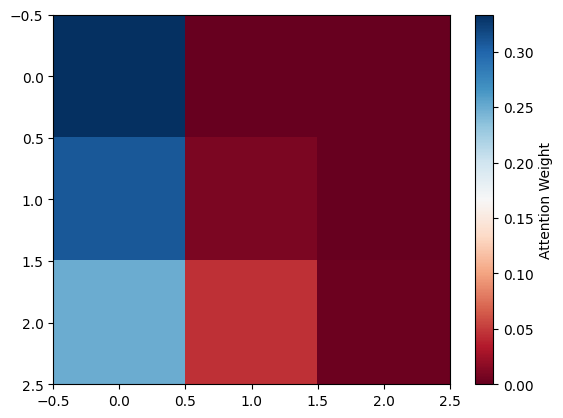

In [13]:
import matplotlib.pyplot as plt

text_id = "26cf6486504fbb09"
model_name = MODEL_NAME
layer, head = 12, 5

matrix = np.load(f"avg_matrix/{model_name}/{text_id}/{layer}_{head}.npy")

plt.imshow(matrix, cmap="RdBu", aspect="auto")
plt.colorbar(label="Attention Weight")
plt.show()

In [14]:
graph_prompt = """Graph 1: a -link-> b. b -link-> c. b -link-> d.
    Graph 2: z -link-> y. y -link-> x. y -link-> w.
    Create a json mapping each node in Graph 1 to its corresponding node in Graph 2.
    <think>\n"""

graph_prompt_sentences = [
    "Graph 1: a -link-> b. b -link-> c. b -link-> d.",
    "Graph 2: z -link-> y. y -link-> x. y -link-> w.",
    "Create a json mapping each node in Graph 1 to its corresponding node in Graph 2.",
    "<think>\n"
]

compute_all_attention_matrices(
    text=graph_prompt,
    model_name=MODEL_NAME,
    sentences=graph_prompt_sentences,
)

Saving avg. matrices:   0%|          | 0/28 [00:00<?, ?it/s]

Saved to avg_matrix/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/8f8bbbba10b980de/27_11.npy


True

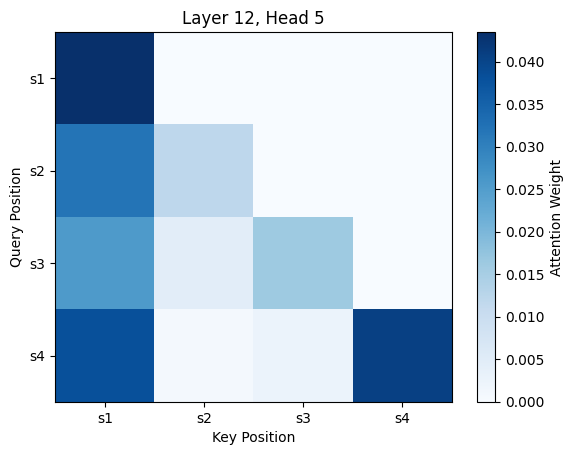

Matrix shape: (4, 4)
Max attention: 0.043478261679410934
Average attention: 0.013502836227416992


In [23]:
import matplotlib.pyplot as plt

text_id = "8f8bbbba10b980de"
model_name = MODEL_NAME
layer, head = 12, 5

matrix = np.load(f"avg_matrix/{model_name}/{text_id}/{layer}_{head}.npy")

plt.imshow(matrix, cmap="Blues", aspect="auto")
plt.colorbar(label="Attention Weight")
plt.xlabel('Key Position')
plt.ylabel('Query Position')
plt.xticks(ticks=[i for i in range(4)], labels=[f's{i+1}' for i in range(4)])
plt.yticks(ticks=[i for i in range(4)], labels=[f's{i+1}' for i in range(4)])
plt.title(f'Layer {layer}, Head {head}')
plt.show()

# Analyze specific patterns
print(f"Matrix shape: {matrix.shape}")
print(f"Max attention: {matrix.max()}")
print(f"Average attention: {matrix.mean()}")

# Compare across heads/layers
matrices = []
for h in range(12):
    mat = np.load(f"avg_matrix/{model_name}/{text_id}/{layer}_{h}.npy")
    matrices.append(mat)

In [16]:
from scipy import stats
from typing import Optional, List

def get_avg_attention_matrix(
    text: str,
    model_name: str,
    layer: int,
    head: int,
    sentences: Optional[List[str]],
    device_map: str = "auto",
    cache_dir: Optional[str] = "attn_cache",
    text_id: Optional[str] = None,
    force_recompute: bool = False
) -> np.ndarray:
    """
    Get averaged attention matrix for a specific layer and head.
    """
    if cache_dir and not text_id:
        text_id = generate_text_hash(text, sentences)
    
    if cache_dir and text_id:
        success = compute_all_attention_matrices(
            text=text,
            model_name=model_name,
            sentences=sentences,
            cache_dir=cache_dir,
            text_id=text_id,
            device_map=device_map,
        )
        if success:
            cache_path = get_cache_path(cache_dir, text_id, model_name, layer, head)
            if os.path.exists(cache_path):
                return np.load(cache_path)
            
    matrix = get_attention_matrix(text, model_name, layer, head, device_map)

    if sentences is None:
        return matrix

    sentence_boundaries = get_sentence_token_boundaries(text, sentences, model_name)

    result = compute_averaged_matrix(matrix, sentence_boundaries)

    if cache_dir and text_id:
        cache_path = get_cache_path(cache_dir, text_id, model_name, layer, head)
        Path(cache_path).parent.mkdir(parents=True, exist_ok=True)
        np.save(cache_path, result)
    
    return result

def get_vertical_scores(
    avg_matrix: np.ndarray,
    proximity_ignore: int = 20,
    control_depth: bool = True,
    score_type: str = "mean",
) -> np.ndarray:
    """
    Calculate vertical attention scores from an averaged attention matrix.
    """
    # Clean the matrix - set upper triangle to NaN
    n = avg_matrix.shape[0]
    trius = np.triu_indices_from(avg_matrix, k=1)

    avg_mat = avg_matrix.copy()
    avg_mat[trius] = np.nan

    trils = np.triu_indices_from(
        avg_mat, k=-proximity_ignore + 1
    ) # has no effect if not subtracting avg
    avg_mat[trils] = np.nan

    if control_depth:
        per_row = np.sum(~np.isnan(avg_mat), axis=1)
        avg_mat = stats.rankdata(avg_mat, axis=1, nan_policy="omit") / per_row[:, None]

    n = avg_mat.shape[-1]
    vert_scores = []

    for i in range(n):
        vert_lines = avg_mat[i + proximity_ignore :, i]

        if score_type == "mean":
            vert_score = np.nanmean(vert_lines)
        elif score_type == "median":
            vert_score == np.nanmedian(vert_lines)
        else:
            raise ValueError(f"Unknown score_type: {score_type}")
        
        vert_scores.append(vert_scores)

    return np.array(vert_scores)



In [ ]:
get_avg_attention_matrix(
    text=graph_prompt,
    model_name=MODEL_NAME,
    layer=12,
    head=5,
    sentences=graph_prompt_sentences
)

Saving avg. matrices:   0%|          | 0/28 [00:00<?, ?it/s]

Saved to attn_cache/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/8f8bbbba10b980de/27_11.npy


array([[0.04347826, 0.        , 0.        , 0.        ],
       [0.02926728, 0.01443808, 0.        , 0.        ],
       [0.02477133, 0.00642668, 0.01400022, 0.        ],
       [0.03073067, 0.00214339, 0.00297964, 0.1683406 ]], dtype=float32)

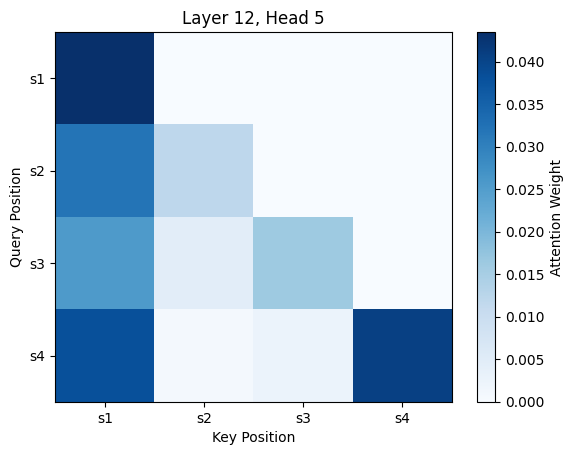

Matrix shape: (4, 4)
Max attention: 0.043478261679410934
Average attention: 0.013502836227416992


In [26]:
import matplotlib.pyplot as plt

text_id = "8f8bbbba10b980de"
model_name = MODEL_NAME
layer, head = 12, 5

matrix = np.load(f"avg_matrix/{model_name}/{text_id}/{layer}_{head}.npy")

plt.imshow(matrix, cmap="Blues", aspect="auto")
plt.colorbar(label="Attention Weight")
plt.xlabel('Key Position')
plt.ylabel('Query Position')
plt.xticks(ticks=[i for i in range(4)], labels=[f's{i+1}' for i in range(4)])
plt.yticks(ticks=[i for i in range(4)], labels=[f's{i+1}' for i in range(4)])
plt.title(f'Layer {layer}, Head {head}')
plt.show()

# Analyze specific patterns
print(f"Matrix shape: {matrix.shape}")
print(f"Max attention: {matrix.max()}")
print(f"Average attention: {matrix.mean()}")

# Compare across heads/layers
matrices = []
for h in range(12):
    mat = np.load(f"avg_matrix/{model_name}/{text_id}/{layer}_{h}.npy")
    matrices.append(mat)

In [27]:
def get_attention_to_step(
    text: str,
    model_name: str,
    layer: int,
    head: int,
    step_idx: int,
    sentences: List[str],
    device_map: str = "auto",
    cache_dir: Optional[str] = "attn_cache"
) -> np.ndarray:
    """
    Get attention from all tokens to a specific step/sentence.
    """
    avg_matrix = get_avg_attention_matrix(
        text,
        model_name,
        layer,
        head,
        sentences,
        device_map,
        cache_dir=cache_dir,
    )

    return avg_matrix[:, step_idx]